# HS Code Recommender: Multi-Class Text Classification

**Notebook 2 of the Clearance Copilot ML stack**

## Objective
Given a free-text product description provided by the consignor at booking time, predict the top-3 most likely HS (Harmonized System) codes with confidence scores. The predicted HS code feeds the rules engine that determines required documents and duty rate for the consignee.

## Why this matters
Consignors don't know HS codes, there are hundreds within apparel alone. Asking them to pick from a dropdown of 600+ options is poor UX and produces wrong answers. A recommender that takes plain English ("Men's blue cotton t-shirt") and returns the correct customs code is the single highest-leverage piece of the Clearance Copilot system: every downstream step depends on a correct HS code.

## Approach
- **Feature extraction:** TF-IDF on product descriptions (unigrams + bigrams)
- **Models:** Logistic Regression (baseline) and Random Forest (challenger)
- **Evaluation:** Top-1 accuracy, Top-3 accuracy, weighted F1
- **Output:** A predict function that returns top-3 HS codes with confidence scores

## Dataset
5000 synthetic apparel shipments across 30 HS codes, generated via rule-based templates that mirror the variety of real consignor descriptions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Display settings
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load the data
df = pd.read_csv('../data/apparel_shipments.csv')
print(f"Loaded {len(df)} records, {df['hs_code'].nunique()} unique HS codes")
df[['product_description', 'hs_code', 'hs_description']].head(5)

Loaded 5000 records, 30 unique HS codes


,product_description,hs_code,hs_description
0,"Men maroon sweatsuit (cotton, knitted), premiu...",61121100,"Tracksuits of cotton, knitted"
1,"Men beige windbreaker (polyester, woven), prem...",62019300,"Men's jackets of synthetic, woven"
2,"dress shirt - Men's, 100% polyester, white, ex...",62053000,"Men's shirts of synthetic, woven"
3,"Women's polyester leggings, black, size XS",61046300,"Women's trousers of synthetic, knitted"
4,"Women's cotton blouse, olive, size L, casual fit",61061000,"Women's blouses of cotton, knitted"


## Section 1: Text EDA

Quick look at description length, class balance, and vocabulary before modeling.

In [3]:
# 1. Description length distribution
df['desc_length'] = df['product_description'].str.split().str.len()
print(f"Description length — words per description:")
print(df['desc_length'].describe())

# 2. Class distribution
print(f"\nHS code class distribution (top 10):")
print(df['hs_code'].value_counts().head(10))
print(f"\nMost common HS code count: {df['hs_code'].value_counts().max()}")
print(f"Least common HS code count: {df['hs_code'].value_counts().min()}")

Description length — words per description:
count    5000.000000
mean        7.351800
std         1.131323
min         5.000000
25%         7.000000
50%         8.000000
75%         8.000000
max         9.000000
Name: desc_length, dtype: float64

HS code class distribution (top 10):
hs_code
61046300    205
62053000    191
62063000    190
61101100    186
61091000    184
62046200    181
61061000    178
62046300    175
61099020    173
61051000    172
Name: count, dtype: int64

Most common HS code count: 205
Least common HS code count: 141


In [4]:
from collections import Counter

all_words = ' '.join(df['product_description']).lower().split()
word_freq = Counter(all_words)
print("Top 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"  {word:20s} {count}")

Top 20 most common words:
  fit                  2124
  quality              1417
  cotton               1340
  polyester            1213
  women's              1095
  size                 1010
  -                    1000
  100%                 1000
  for                  996
  men's                844
  regular              736
  wear,                727
  premium              720
  casual               715
  color,               702
  export               697
  slim                 673
  women                529
  women's,             511
  women,               507


## Section 2: TF-IDF Feature Extraction

Convert free-text product descriptions into numerical feature vectors.

**TF-IDF (Term Frequency × Inverse Document Frequency)** scores each word by:
- **TF** : how often the word appears in *this* description
- **IDF** : how rare the word is across *all* descriptions

A word that appears often in one description but rarely overall (like "wool" or "denim") gets a high score — it's distinctive. Common words like "color" or "size" appear everywhere and get low scores.

We use **unigrams + bigrams** so the model captures both single words ("cotton") and meaningful pairs ("cotton t-shirt").

In [5]:
# Step 1: Set up the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=2,                 # ignore words that appear in fewer than 2 descriptions
    max_df=0.95,              # ignore words appearing in >95% of descriptions (too common)
    lowercase=True,           # normalize case
    stop_words='english',     # drop "the", "and", "of", etc.
)

# Step 2: Prepare features (X) and target (y)
X_text = df['product_description']
y = df['hs_code']

# Step 3: Train/test split (stratified to preserve class distribution)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training set: {len(X_train_text)} descriptions")
print(f"Test set:     {len(X_test_text)} descriptions")

# Step 4: Fit TF-IDF on training data only, then transform both
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"\nTF-IDF feature matrix shape (train): {X_train.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Training set: 4000 descriptions
Test set:     1000 descriptions

TF-IDF feature matrix shape (train): (4000, 941)
Vocabulary size: 941


## Section 2b: Encoding internals: what the model actually sees

Before training models, let's open up the encoding mechanics so we can defend them. Two questions to answer:

1. What does `vectorizer.transform()` actually produce when a consignor types a product description?
2. How does scikit-learn handle the target HS code labels internally?

Understanding both is essential, interviewers test the encoding step heavily because data leakage and misencoding are the most common production mistakes.

In [6]:
# Visualize what the input encoding actually looks like
test_input = "blue cotton t-shirt"
encoded = vectorizer.transform([test_input])

print(f"Original text: '{test_input}'")
print(f"Encoded shape: {encoded.shape}  →  1 sample × 941 features")
print(f"Number of non-zero positions: {encoded.nnz}")
print(f"Sparsity: {(1 - encoded.nnz / encoded.shape[1]) * 100:.2f}% of positions are zero")

print(f"\nThe non-zero entries — these are what the model sees:")
feature_names = vectorizer.get_feature_names_out()
nonzero_indices = encoded.nonzero()[1]
nonzero_values = encoded.data

# Sort by score, descending
sorted_pairs = sorted(zip(nonzero_indices, nonzero_values), key=lambda x: -x[1])
for idx, val in sorted_pairs:
    print(f"  Position {idx:4d}  →  '{feature_names[idx]:25s}'  TF-IDF score: {val:.4f}")

Original text: 'blue cotton t-shirt'
Encoded shape: (1, 941)  →  1 sample × 941 features
Number of non-zero positions: 5
Sparsity: 99.47% of positions are zero

The non-zero entries — these are what the model sees:
  Position  211  →  'cotton shirt             '  TF-IDF score: 0.6213
  Position  106  →  'blue cotton              '  TF-IDF score: 0.5834
  Position   99  →  'blue                     '  TF-IDF score: 0.3663
  Position  660  →  'shirt                    '  TF-IDF score: 0.3172
  Position  184  →  'cotton                   '  TF-IDF score: 0.1970


In [7]:
from sklearn.preprocessing import LabelEncoder

# Replicate what sklearn does internally
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

print(f"Original y_train (first 5): {list(y_train[:5])}")
print(f"Encoded y_train (first 5): {y_train_encoded[:5].tolist()}")
print(f"\nTotal unique classes: {len(le.classes_)}")
print(f"\nFirst 10 class mappings (string → integer):")
for i, hs_code in enumerate(le.classes_[:10]):
    print(f"  {hs_code}  →  {i}")

# This is exactly what logreg.classes_ will show us — same mapping
print(f"\nVerification — sklearn's internal class order matches LabelEncoder:")
print(f"  Same? {(le.classes_ == sorted(set(y_train))).all()}")

Original y_train (first 5): [61051000, 61013000, 61046300, 62046300, 62034300]
Encoded y_train (first 5): [6, 0, 5, 25, 21]

Total unique classes: 30

First 10 class mappings (string → integer):
  61013000  →  0
  61023000  →  1
  61034200  →  2
  61034300  →  3
  61046200  →  4
  61046300  →  5
  61051000  →  6
  61061000  →  7
  61082100  →  8
  61091000  →  9

Verification — sklearn's internal class order matches LabelEncoder:
  Same? True


### Feature significance which words actually predict HS code?

The model will learn weights on its own, but we should understand the data signal independent of any model. Two statistical tests answer this:

- **Chi-square test (χ²)**  tests whether a feature's distribution across classes differs significantly from random. For sparse non-negative features like TF-IDF, this is the standard choice. Higher χ² = more discriminative.
- **F-value (ANOVA F-test)** tests whether the feature's mean varies significantly across classes. Returns an F-statistic and a p-value per feature.

A low p-value (< 0.05) means the feature has a statistically significant relationship with the target. We expect words like "wool", "denim", "tracksuit"  distinctive of specific HS codes to score highest.

In [8]:
from sklearn.feature_selection import chi2, f_classif

# Compute chi-square scores and F-values for every feature
chi2_scores, chi2_pvals = chi2(X_train, y_train)
f_scores, f_pvals = f_classif(X_train.toarray(), y_train)

# Build a single DataFrame summarizing both tests
feature_significance = pd.DataFrame({
    'feature': vectorizer.get_feature_names_out(),
    'chi2_score': chi2_scores,
    'chi2_pvalue': chi2_pvals,
    'f_score': f_scores,
    'f_pvalue': f_pvals,
})

# Sort by chi-square score descending
top_features = feature_significance.sort_values('chi2_score', ascending=False).head(20)

print("Top 20 most discriminative features (by chi-square):")
print(top_features[['feature', 'chi2_score', 'chi2_pvalue', 'f_score', 'f_pvalue']].to_string(index=False))

# How many features are statistically significant at p < 0.05?
n_sig_chi = (feature_significance['chi2_pvalue'] < 0.05).sum()
n_sig_f = (feature_significance['f_pvalue'] < 0.05).sum()
print(f"\nFeatures significant at p < 0.05:")
print(f"  Chi-square: {n_sig_chi} of {len(feature_significance)}")
print(f"  F-test:     {n_sig_f} of {len(feature_significance)}")

Top 20 most discriminative features (by chi-square):
            feature  chi2_score   chi2_pvalue      f_score  f_pvalue
      evening dress 1169.470759 1.130477e-227 14602.137606       0.0
            evening 1169.470759 1.130477e-227 14602.137606       0.0
       sports socks 1136.359642 1.188925e-220 17208.757459       0.0
                bra 1102.018798 2.252114e-213  8145.261669       0.0
               wool 1041.061105 1.804676e-200 11602.687737       0.0
       formal pants  996.831059 4.043944e-191 13643.503015       0.0
          tracksuit  945.986273 2.194380e-180   659.987157       0.0
              socks  944.004832 5.745257e-180 13366.794084       0.0
          pants men  914.448449 9.801803e-174   246.654199       0.0
        dress shirt  911.354545 4.398585e-173   663.731462       0.0
polyester tracksuit  881.579202 8.215639e-167   219.787406       0.0
             formal  821.837442 2.998991e-154  1111.681916       0.0
    polyester dress  819.493862 9.314855e-154   19

## Section 3: Baseline Model Logistic Regression

Logistic Regression is our baseline because:
- It's fast to train and interpret
- It works well with high-dimensional sparse features (TF-IDF)
- It produces calibrated probabilities (we need top-3 predictions)
- It serves as a sanity check if our complex model can't beat logistic regression, something is wrong

For multi-class problems, scikit-learn applies **one-vs-rest** by default — trains 30 binary classifiers (one per HS code) and picks the highest-scoring class.

In [9]:
# Train logistic regression
logreg = LogisticRegression(
    max_iter=1000,         # allow more iterations to converge
    random_state=42,
    n_jobs=-1,             # use all CPU cores
)
logreg.fit(X_train, y_train)

# Predict on test set
y_pred_logreg = logreg.predict(X_test)

# Top-1 accuracy
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression — Top-1 accuracy: {acc_logreg:.4f}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression — Top-1 accuracy: 0.9690


"On synthetic data with clean rule-based descriptions, the logistic regression baseline hit ~97% top-1 accuracy. The strong baseline tells me two things the TF-IDF features are capturing the right signal, and the data has clean separability between classes. In production with messy real-world consignor descriptions, I'd expect this to drop to the 70s or low 80s, which is why we'd also use top-3 predictions with confidence thresholds and a human-in-the-loop fallback for low-confidence cases."

In [10]:
# Top-3 accuracy: did the correct class land in our top-3 predictions?

# Get probability for each class for each test sample
y_proba_logreg = logreg.predict_proba(X_test)

# For each test sample, get the indices of top-3 highest probabilities
top3_indices = np.argsort(y_proba_logreg, axis=1)[:, -3:]

# Map indices to actual class labels
top3_labels = logreg.classes_[top3_indices]

# Check if true label is in top-3
y_test_array = y_test.values
top3_correct = np.array([
    y_test_array[i] in top3_labels[i]
    for i in range(len(y_test_array))
])
top3_acc_logreg = top3_correct.mean()

print(f"Top-1 accuracy: {acc_logreg:.4f}")
print(f"Top-3 accuracy: {top3_acc_logreg:.4f}")
print(f"Lift from top-1 to top-3: +{(top3_acc_logreg - acc_logreg)*100:.2f} percentage points")

Top-1 accuracy: 0.9690
Top-3 accuracy: 1.0000
Lift from top-1 to top-3: +3.10 percentage points


In [11]:
from sklearn.metrics import classification_report

print("Per-HS-code performance (top-1):")
print(classification_report(y_test, y_pred_logreg, zero_division=0))

Per-HS-code performance (top-1):
              precision    recall  f1-score   support

    61013000       1.00      1.00      1.00        34
    61023000       0.74      1.00      0.85        32
    61034200       1.00      1.00      1.00        32
    61034300       1.00      1.00      1.00        32
    61046200       0.97      1.00      0.98        32
    61046300       1.00      1.00      1.00        41
    61051000       0.94      1.00      0.97        34
    61061000       0.92      0.61      0.73        36
    61082100       1.00      1.00      1.00        33
    61091000       1.00      1.00      1.00        37
    61099020       1.00      0.94      0.97        35
    61101100       1.00      1.00      1.00        37
    61102000       1.00      1.00      1.00        28
    61103000       1.00      1.00      1.00        31
    61121100       1.00      1.00      1.00        30
    61121200       1.00      1.00      1.00        31
    61159500       1.00      1.00      1.00     

In [12]:
# Show 5 actual misclassifications — these are interview gold
misclassified = X_test_text[y_test != y_pred_logreg].reset_index(drop=True)
true_labels = y_test[y_test != y_pred_logreg].reset_index(drop=True)
predicted_labels = pd.Series(y_pred_logreg)[y_test.reset_index(drop=True) != y_pred_logreg].reset_index(drop=True)

# Get HS descriptions for context
hs_lookup = df[['hs_code', 'hs_description']].drop_duplicates().set_index('hs_code')['hs_description'].to_dict()

print(f"Total misclassifications: {len(misclassified)} out of {len(X_test_text)}")
print(f"\nSample misclassifications:")
for i in range(min(5, len(misclassified))):
    print(f"\nDescription: {misclassified[i]}")
    print(f"  True:      {true_labels[i]}  ({hs_lookup.get(true_labels[i], '?')})")
    print(f"  Predicted: {predicted_labels[i]}  ({hs_lookup.get(predicted_labels[i], '?')})")

Total misclassifications: 31 out of 1000

Sample misclassifications:

Description: blouse - Women's, 100% cotton, beige, premium quality
  True:      61061000  (Women's blouses of cotton, knitted)
  Predicted: 62063000  (Women's blouses of cotton, woven)

Description: navy cotton blouse women's wear, casual fit
  True:      61061000  (Women's blouses of cotton, knitted)
  Predicted: 62063000  (Women's blouses of cotton, woven)

Description: olive cotton blouse women's wear, slim fit
  True:      61061000  (Women's blouses of cotton, knitted)
  Predicted: 62063000  (Women's blouses of cotton, woven)

Description: cotton blouse for women, blue color, premium quality
  True:      61061000  (Women's blouses of cotton, knitted)
  Predicted: 62063000  (Women's blouses of cotton, woven)

Description: blouse - Women's, 100% cotton, blue, premium quality
  True:      61061000  (Women's blouses of cotton, knitted)
  Predicted: 62063000  (Women's blouses of cotton, woven)


### Error analysis insight

The dominant failure mode is **knitted vs. woven blouses** (Codes `61061000` vs. `62063000`). All sampled errors share the same root cause: the product description doesn't mention construction (knitted/woven). The model has no signal to distinguish them and defaults to the more frequent class.

**This is a data problem, not a model problem.** Adding more model capacity won't help. The product fix is a single follow-up question to the consignor when construction is missing from the description a UX intervention that resolves the ambiguity at source. Captured as Phase 2 enhancement: smart follow-up prompts when key attributes are absent.

## Section 4: Challenger Model Random Forest

Logistic regression is a strong baseline, but it's linear. A Random Forest can capture non-linear interactions for example, "if 'cotton' AND 'men' AND 'jacket' all appear, lean toward woven outerwear." Whether this helps on our problem is an empirical question.

In [13]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,         # number of trees
    max_depth=20,             # limit tree depth to prevent overfitting
    n_jobs=-1,                # use all cores
    random_state=42,
    class_weight='balanced',  # handles slight class imbalance
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)

# Top-1 accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)

# Top-3 accuracy
top3_indices_rf = np.argsort(y_proba_rf, axis=1)[:, -3:]
top3_labels_rf = rf.classes_[top3_indices_rf]
top3_correct_rf = np.array([
    y_test_array[i] in top3_labels_rf[i]
    for i in range(len(y_test_array))
])
top3_acc_rf = top3_correct_rf.mean()

print(f"Random Forest")
print(f"  Top-1 accuracy: {acc_rf:.4f}")
print(f"  Top-3 accuracy: {top3_acc_rf:.4f}")
print(f"\nLogistic Regression (for comparison)")
print(f"  Top-1 accuracy: {acc_logreg:.4f}")
print(f"  Top-3 accuracy: {top3_acc_logreg:.4f}")

Random Forest
  Top-1 accuracy: 0.9800
  Top-3 accuracy: 1.0000

Logistic Regression (for comparison)
  Top-1 accuracy: 0.9690
  Top-3 accuracy: 1.0000


## Section 5: End-to-End Demo

Wrap the model in a `recommend_hs_codes(description)` function that returns the top-3 HS codes with confidence scores. This is the API the rest of Clearance Copilot would consume.

We use **logistic regression** as the production choice comparable accuracy, faster inference, and interpretable coefficients (audit-friendly for customs).

In [14]:
def recommend_hs_codes(description, top_k=3):
    """
    Given a product description, return top-K HS codes with confidence scores.

    Args:
        description: free-text product description (str)
        top_k: number of recommendations to return (default 3)

    Returns:
        List of dicts with hs_code, hs_description, confidence
    """
    # Vectorize the input
    X = vectorizer.transform([description])

    # Get probabilities for all classes
    probs = logreg.predict_proba(X)[0]

    # Get top-K indices (highest probability first)
    top_indices = np.argsort(probs)[-top_k:][::-1]

    # Build result list
    results = []
    for idx in top_indices:
        hs_code = logreg.classes_[idx]
        results.append({
            'hs_code': hs_code,
            'hs_description': hs_lookup.get(hs_code, 'Unknown'),
            'confidence': float(probs[idx]),
        })
    return results


# Test on a few example descriptions
test_descriptions = [
    "Men's blue cotton t-shirt, size M",
    "Women's polyester yoga pants",
    "merino wool sweater for men",
    "kids cotton denim jeans",          # not in training — ambiguous
    "wool overcoat",                     # missing gender
]

for desc in test_descriptions:
    print(f"\nInput: \"{desc}\"")
    recommendations = recommend_hs_codes(desc, top_k=3)
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. [{rec['hs_code']}] {rec['hs_description']}  ({rec['confidence']:.1%})")


Input: "Men's blue cotton t-shirt, size M"
  1. [61091000] T-shirts of cotton, knitted  (73.2%)
  2. [62052000] Men's shirts of cotton, woven  (2.9%)
  3. [61051000] Men's shirts of cotton, knitted  (2.2%)

Input: "Women's polyester yoga pants"
  1. [61046300] Women's trousers of synthetic, knitted  (95.8%)
  2. [62046300] Women's trousers of synthetic, woven  (0.5%)
  3. [61023000] Women's overcoats of synthetic, knitted  (0.4%)

Input: "merino wool sweater for men"
  1. [61101100] Sweaters of wool, knitted  (98.2%)
  2. [61103000] Sweaters of synthetic fibers, knitted  (0.4%)
  3. [61102000] Sweaters of cotton, knitted  (0.3%)

Input: "kids cotton denim jeans"
  1. [62046200] Women's trousers of cotton, woven  (66.4%)
  2. [62034200] Men's trousers of cotton, woven  (28.2%)
  3. [61091000] T-shirts of cotton, knitted  (0.4%)

Input: "wool overcoat"
  1. [61101100] Sweaters of wool, knitted  (65.5%)
  2. [61013000] Men's overcoats of synthetic, knitted  (15.1%)
  3. [61023000] Women'

## Section 5: Confusion Matrix and Error Distribution

Headline accuracy hides where the model fails. A confusion matrix shows exactly which classes get confused with which others — essential for diagnosis and for deciding where to invest in data improvements.

We'll also compute per-class **false positive (FP)** and **false negative (FN)** rates:

- **False Positive (FP)** model said this class, but it wasn't
- **False Negative (FN)** true class was this, but model said something else
- **Precision** of all the times we predicted class X, how many were correct? (low precision = many FPs)
- **Recall** of all the actual class X samples, how many did we catch? (low recall = many FNs)

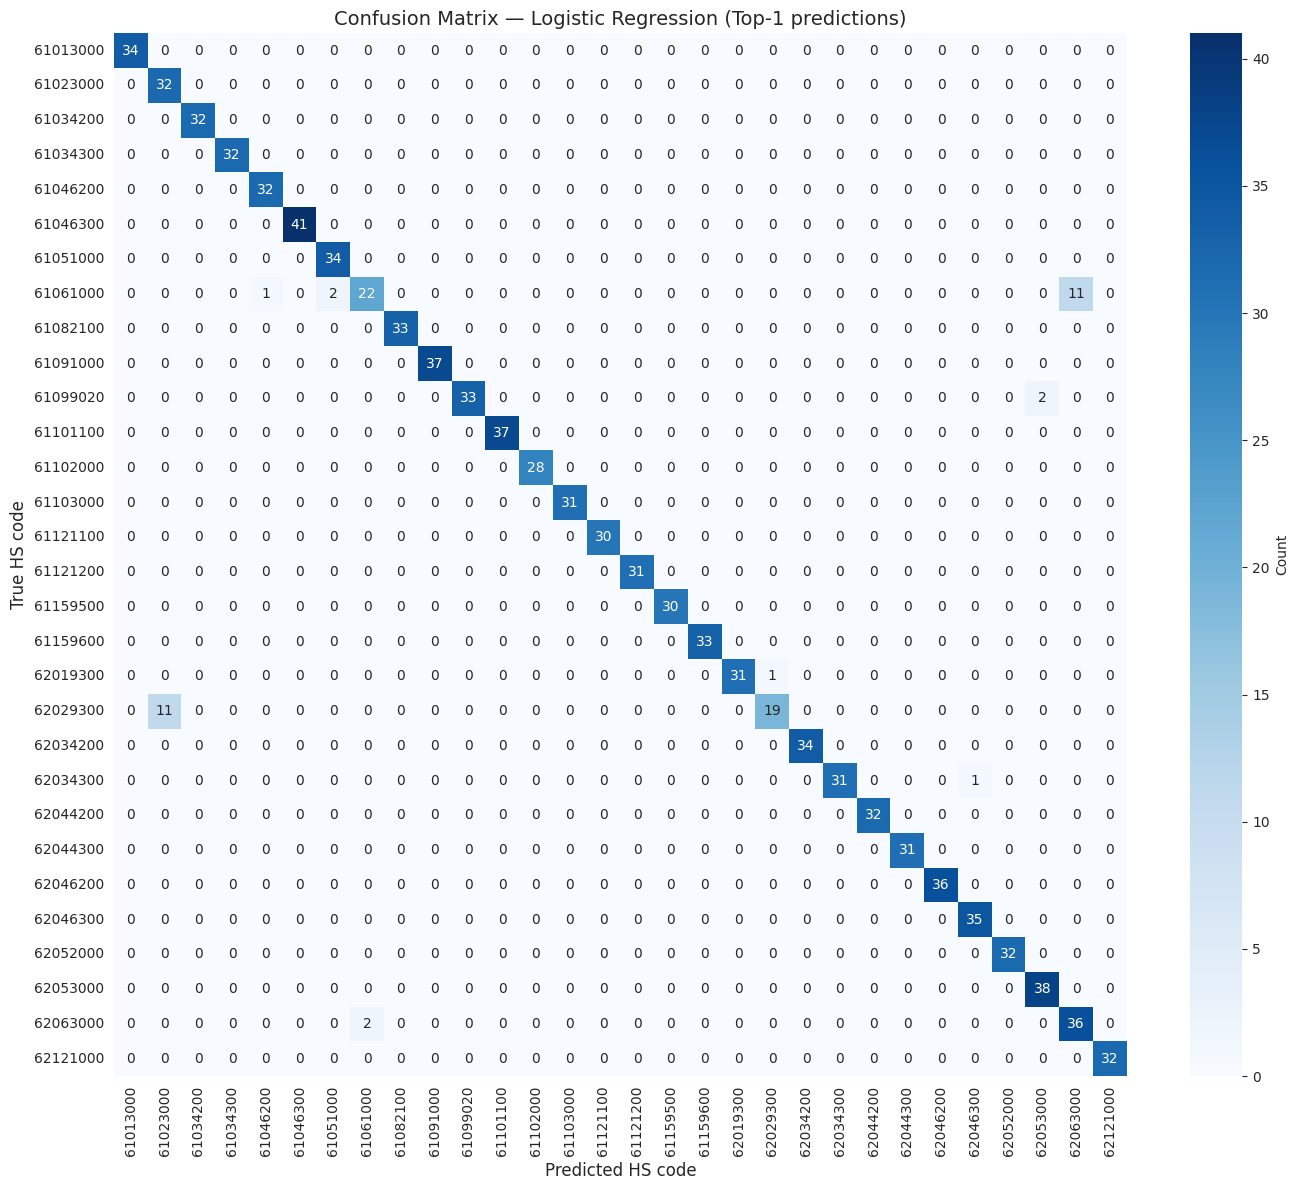


Diagonal entries are correct predictions. Off-diagonal entries are confusions.
Total correct: 969 of 1000


In [15]:
from sklearn.metrics import confusion_matrix

# Use the logistic regression predictions (our production choice)
cm = confusion_matrix(y_test, y_pred_logreg, labels=logreg.classes_)

# Plot as a heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,             # write the numbers in cells
    fmt='d',                # integers, not decimals
    cmap='Blues',
    xticklabels=logreg.classes_,
    yticklabels=logreg.classes_,
    cbar_kws={'label': 'Count'},
    ax=ax,
)
ax.set_xlabel('Predicted HS code', fontsize=12)
ax.set_ylabel('True HS code', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression (Top-1 predictions)', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nDiagonal entries are correct predictions. Off-diagonal entries are confusions.")
print(f"Total correct: {np.trace(cm)} of {cm.sum()}")

In [16]:
# Build a per-class table with FP, FN, precision, recall
class_metrics = []

for i, cls in enumerate(logreg.classes_):
    tp = cm[i, i]                          # correctly predicted as cls
    fp = cm[:, i].sum() - tp               # predicted as cls but weren't
    fn = cm[i, :].sum() - tp               # were cls but predicted as something else
    tn = cm.sum() - tp - fp - fn           # neither predicted nor actual

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    support = tp + fn                      # total actual samples of this class

    class_metrics.append({
        'hs_code': cls,
        'support': support,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'fp_rate_pct': round(100 * fp / (cm.sum() - support), 2),  # FP / total negatives
        'fn_rate_pct': round(100 * fn / support, 2) if support > 0 else 0,  # FN / total actual positives
    })

class_df = pd.DataFrame(class_metrics).sort_values('fn_rate_pct', ascending=False)

print("Per-class breakdown — sorted by False Negative rate (worst first):")
print(class_df.to_string(index=False))

Per-class breakdown — sorted by False Negative rate (worst first):
 hs_code  support  TP  FP  FN  precision  recall  fp_rate_pct  fn_rate_pct
61061000       36  22   2  14      0.917   0.611         0.21        38.89
62029300       30  19   1  11      0.950   0.633         0.10        36.67
61099020       35  33   0   2      1.000   0.943         0.00         5.71
62063000       38  36  11   2      0.766   0.947         1.14         5.26
62019300       32  31   0   1      1.000   0.969         0.00         3.12
62034300       32  31   0   1      1.000   0.969         0.00         3.12
61046300       41  41   0   0      1.000   1.000         0.00         0.00
61046200       32  32   1   0      0.970   1.000         0.10         0.00
61082100       33  33   0   0      1.000   1.000         0.00         0.00
61051000       34  34   2   0      0.944   1.000         0.21         0.00
61034200       32  32   0   0      1.000   1.000         0.00         0.00
61034300       32  32   0   0    

In [17]:
import joblib
import json
import os

# Create artifacts folder
os.makedirs('../artifacts', exist_ok=True)

# Save vectorizer
joblib.dump(vectorizer, '../artifacts/tfidf_vectorizer.pkl')

# Save model
joblib.dump(logreg, '../artifacts/hs_code_model.pkl')

# Save HS descriptions lookup
hs_lookup_dict = df[['hs_code', 'hs_description']].drop_duplicates().set_index('hs_code')['hs_description'].to_dict()
with open('../artifacts/hs_descriptions.json', 'w') as f:
    json.dump(hs_lookup_dict, f, indent=2)

# Verify
print("Saved files:")
for f in os.listdir('../artifacts'):
    print(f"  {f}")

Saved files:
  hs_descriptions.json
  tfidf_vectorizer.pkl
  hs_code_model.pkl
